<a href="https://colab.research.google.com/github/georgerieh/ml-ai-code-studies/blob/main/clothes_classifier_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
from torchvision.io import decode_image
from torch.utils.data import Dataset, random_split, Subset
import torch


class_dict = {
    '1':'upper-body clothes',
    '2':'lower-body clothes',
    '3':'full-body clothes'
}
def get_class_name(c_id):
    return class_dict[str(c_id)]

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1), # Converts to Grayscale
    transforms.ToTensor(),                       # [0, 255] -> [0, 1]
    transforms.Normalize((0.5,), (0.5,))         # [0, 1] -> [-1, 1]
])


class FashionDataset(Dataset):
    def __init__(self, img_dir, annotations_file, transform=transform, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file, sep=r'\s+', skiprows=1)

        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label, idx






In [4]:
!unzip -q '/content/drive/MyDrive/fashion/Копия img.zip' -d 'img'

In [5]:
!cp '/content/drive/MyDrive/fashion/Копия list_landmarks.txt' 'list_landmarks.txt'

In [6]:

dataset = FashionDataset("img/", "list_landmarks.txt", transform=transform)

num_samples = 50000
indices = np.random.choice(len(dataset), num_samples, replace=False)



small_subset = Subset(dataset, indices)

train_size = int(0.8 * num_samples)
test_size = num_samples - train_size


train_dataset, test_dataset = random_split(small_subset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)






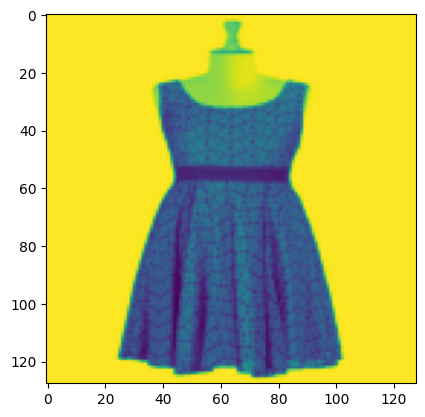

Label: full-body clothes
tensor(84499)


In [7]:
train_features, train_labels, idx = next(iter(train_loader))
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img)
plt.show()
print(f"Label: {get_class_name(label.item())}")
print(idx[0])

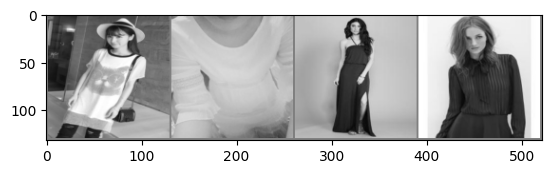

full-body clothes||full-body clothes||full-body clothes||upper-body clothes


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()

    # If the image is grayscale (1 channel), squeeze it to (256, 256)
    if npimg.shape[0] == 1:
        plt.imshow(npimg[0], cmap='gray')
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels, idx = next(dataiter)
ims, lbs = images[:4], labels[:4]
# show images
imshow(torchvision.utils.make_grid(ims))
# print labels
print('||'.join(f'{get_class_name(lbs[j].item()):5s}' for j in range(4)))

In [9]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        '''
        # Calculate the correct input when input is 256x256 features for fc1 based on image size 256x256
        # Output size after conv1: (256 - 5 + 1) = 252
        # Output size after pool1: 252 / 2 = 126
        # Output size after conv2: (126 - 5 + 1) = 122
        # Output size after pool2: 122 / 2 = 61
        # So, the flattened size is 16 * 61 * 61
        '''
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 29 * 29, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 3) # 3 final classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


net = Net()

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [11]:
from tqdm import tqdm
for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(tqdm(train_loader), 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels, idx = data
        labels = labels - 1
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        labels = torch.stack(list(labels), dim=0)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 625:.3f}')
    running_loss = 0.0

print('Finished Training')


100%|██████████| 625/625 [02:32<00:00,  4.11it/s]


[1,   625] loss: 1.078


100%|██████████| 625/625 [02:31<00:00,  4.14it/s]


[2,   625] loss: 1.027


100%|██████████| 625/625 [02:31<00:00,  4.13it/s]


...

[8,   625] loss: 0.844


100%|██████████| 625/625 [02:31<00:00,  4.14it/s]


[9,   625] loss: 0.825


100%|██████████| 625/625 [02:30<00:00,  4.14it/s]

[10,   625] loss: 0.801
Finished Training


In [12]:
PATH = './model_not_bbox_net.pth'
torch.save(net.state_dict(), PATH)

In [13]:
net = Net()
net.load_state_dict(torch.load(PATH))
net.train()

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=13456, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=3, bias=True)
)

In [14]:
for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(tqdm(train_loader), 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels, idx = data
        labels = labels - 1
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        labels = torch.stack(list(labels), dim=0)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 625:.3f}')
    running_loss = 0.0

print('Finished Training')

100%|██████████| 625/625 [02:27<00:00,  4.23it/s]


[1,   625] loss: 0.769


100%|██████████| 625/625 [02:27<00:00,  4.23it/s]


[2,   625] loss: 0.769


100%|██████████| 625/625 [02:28<00:00,  4.21it/s]


[3,   625] loss: 0.769


100%|██████████| 625/625 [02:28<00:00,  4.21it/s]


[4,   625] loss: 0.769


 14%|█▍        | 88/625 [00:21<02:10,  4.12it/s]


KeyboardInterrupt: 

In [15]:
PATH = './model_not_bbox_net0.76.pth'
torch.save(net.state_dict(), PATH)

In [16]:
net = Net()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

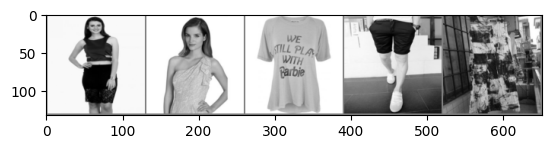

GroundTruth:  lower-body clothes||full-body clothes||upper-body clothes||lower-body clothes||full-body clothes


In [17]:
dataiter = iter(test_loader)
images, labels, idx = next(dataiter)
ims, lbs = images[:5], labels[:5]

# print images
imshow(torchvision.utils.make_grid(ims))
print('GroundTruth: ', '||'.join(f'{get_class_name(lbs[j].item()):5s}' for j in range(5)))

In [18]:
outputs = net(ims)

In [19]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', '||'.join(f'{get_class_name(predicted[j].item()+1):5s}'
                              for j in range(5)))

Predicted:  full-body clothes||upper-body clothes||full-body clothes||lower-body clothes||lower-body clothes


In [20]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels, idx = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted+1 == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 62 %


In [34]:
class FashionDatasetBBox(Dataset):
    def __init__(self, img_dir, bbox_file, joints_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        self.bboxes = pd.read_csv(bbox_file, sep=r'\s+', skiprows=1)

        self.img_labels = pd.read_csv(joints_file, sep=r'\s+', skiprows=1)
    def __len__(self):
        return len(self.img_labels)
    def __getitem__(self, idx):
        img_name = self.bboxes.iloc[idx, 0]
        image = Image.open(os.path.join(self.img_dir, img_name)).convert("RGB")

        x1 = self.bboxes.iloc[idx, 1]
        y1 = self.bboxes.iloc[idx, 2]
        x2 = self.bboxes.iloc[idx, 3]
        y2 = self.bboxes.iloc[idx, 4]

        image = image.crop((x1, y1, x2, y2))

        label = int(self.img_labels.iloc[idx, 1]) - 1

        if self.transform:
            image = self.transform(image)

        return image, label

In [23]:
!cp '/content/drive/MyDrive/fashion/list_bbox.txt' 'list_bbox.txt'

In [27]:
!cp '/content/drive/MyDrive/fashion/list_joints.txt' 'list_joints.txt'

In [39]:
transform = transforms.Compose([

transforms.Resize((128, 128)),

transforms.Grayscale(num_output_channels=1), # Converts to Grayscale

transforms.ToTensor(), # [0, 255] -> [0, 1]

transforms.Normalize((0.5,), (0.5,)) # [0, 1] -> [-1, 1]

])
dataset_cropped = FashionDatasetBBox("img/", "list_bbox.txt", 'list_joints.txt', transform=transform)

num_samples = 50000
indices = np.random.choice(len(dataset_cropped), num_samples, replace=False)



small_subset = Subset(dataset_cropped, indices)

train_size = int(0.8 * num_samples)
test_size = num_samples - train_size


train_dataset, test_dataset = random_split(small_subset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)






In [37]:
from PIL import Image

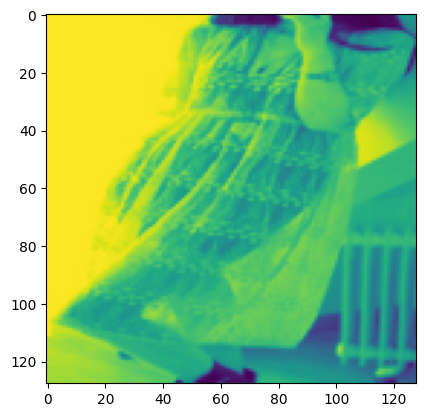

Label: full-body clothes


In [44]:
train_features, train_labels,  = next(iter(train_loader))
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img)
plt.show()
print(f"Label: {get_class_name(label.item()+1)}")

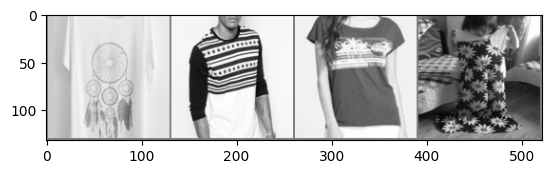

upper-body clothes||upper-body clothes||upper-body clothes||full-body clothes


In [46]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()

    # If the image is grayscale (1 channel), squeeze it to (256, 256)
    if npimg.shape[0] == 1:
        plt.imshow(npimg[0], cmap='gray')
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
ims, lbs = images[:4], labels[:4]
# show images
imshow(torchvision.utils.make_grid(ims))
# print labels
print('||'.join(f'{get_class_name(lbs[j].item()+1):5s}' for j in range(4)))

In [71]:
import torch.nn as nn
import torch.nn.functional as F


class NetCropped(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # Calculate the correct input when input is 256x256 features for fc1 based on image size 256x256
        # Output size after conv1: (256 - 5 + 1) = 252
        # Output size after pool1: 252 / 2 = 126
        # Output size after conv2: (126 - 5 + 1) = 122
        # Output size after pool2: 122 / 2 = 61
        # So, the flattened size is 16 * 61 * 61
        self.fc1 = nn.Linear(16 * 29 * 29, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = NetCropped().to(device)

In [48]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [73]:
from tqdm import tqdm
for epoch in range(15):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(tqdm(train_loader), 0):

        inputs, labels = data
        inputs = inputs.to(device)

        optimizer.zero_grad()


        outputs = net(inputs)
        labels = torch.stack(list(labels), dim=0).to(device)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 625:.3f}')
    running_loss = 0.0

print('Finished Training')


 10%|▉         | 61/625 [00:09<01:32,  6.11it/s]


KeyboardInterrupt: 

In [51]:
PATH = './model_not_bbox_net_cropped.pth'
torch.save(net.state_dict(), PATH)

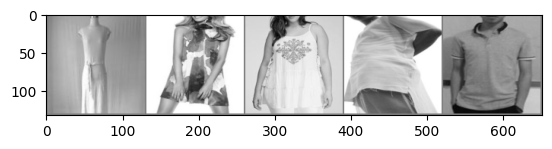

GroundTruth:  full-body clothes||full-body clothes||full-body clothes||upper-body clothes||upper-body clothes


In [53]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
ims, lbs = images[:5], labels[:5]

# print images
imshow(torchvision.utils.make_grid(ims))
print('GroundTruth: ', '||'.join(f'{get_class_name(lbs[j].item()+1):5s}' for j in range(5)))

In [54]:
net = NetCropped()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [55]:
outputs = net(ims)

In [57]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', '||'.join(f'{get_class_name(predicted[j].item()+1):5s}'
                              for j in range(5)))

Predicted:  full-body clothes||full-body clothes||full-body clothes||upper-body clothes||upper-body clothes


In [59]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data

        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 76 %


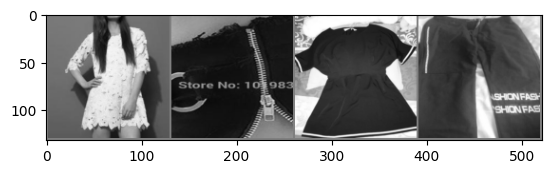

GroundTruth:  full-body clothes||lower-body clothes||full-body clothes||lower-body clothes
Predicted:  full-body clothes||full-body clothes||full-body clothes||lower-body clothes


In [66]:
import random
dataiter = iter(test_loader)
images, labels = next(dataiter)

pairs = list(zip(images, labels))
pairs = random.sample(pairs, 4)
images, labels = zip(*pairs)

ims, lbs = torch.stack(list(images), dim=0), torch.stack(list(labels), dim=0)

# print images
imshow(torchvision.utils.make_grid(ims))
print('GroundTruth: ', '||'.join(f'{get_class_name(lbs[j].item()+1):5s}' for j in range(4)))

outputs = net(ims)
_, predicted = torch.max(outputs, 1)
predicted+=1

print('Predicted: ', '||'.join(f'{get_class_name(predicted[j].item()):5s}'
                              for j in range(4)))

Try-on

In [70]:
from PIL import Image
import torch

def predict_external_image(image_path, model, transform, class_dict):
    img = Image.open(image_path).convert("RGB")

    img_tensor = transform(img)

    img_tensor = img_tensor.unsqueeze(0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    img_tensor = img_tensor.to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)

    class_idx = str(predicted.item()+1)
    return _.item(), class_dict.get(class_idx, "Unknown")

file_in = input()
ground = input('is it upper, lower or full body? - 1, 2, 3')
if int(ground) == 1:
  var = 'upper-body clothes'
elif int(ground) == 2:
  var = 'lower-body clothes'
elif int(ground) == 3:
  var = 'full-body clothes'
_, result = predict_external_image(file_in, net, transform, class_dict)
print(f'You gave:', var)
print(f"The model thinks this is: {result}")

/content/Capture d’écran 2026-01-06 à 18.29.11.png
is it upper, lower or full body? - 1, 2, 33
You gave: full-body clothes
The model thinks this is: full-body clothes
